# 11_model_zoo.ipynb
Finds the optimal hyperparameters for a Random Forst, XGBoost and MLP when the input data is all of the radiomics data.

In [24]:
from pathlib import Path
path = Path.cwd().parent.parent

# Setup parameters for each type of simulation
SETUP = {'PC1': {'X': path / "data" / "interim" / "pc_by_feature_group_for_patients.csv",
                 'hyperparameters_file' : path / "notebooks" / "modeling" / "optimal_params_pc1.json"},
        'PC1_3' : {'X' : path / "data" / "interim" / "pc1_to_3_by_feature_group_for_patients.csv",
                   'hyperparameters_file' : path / "notebooks" / "modeling" / "optimal_params_pc1_to_3.json"},
        'ALL_IMG' : {'X' : path / "data" / "raw" / "imagingFeatures.csv",
                     'hyperparameters_file' : path / "notebooks" / "modeling" / "optimal_params_all_image_features.json"}}

# Each of the models uses a different input- so choose the model that we would like
# to run for this chosen version
MODEL = 'ALL_IMG'

TARGET = 'Mol Subtype'

In [25]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

trainPatientID = (pd.read_csv(path / "data" / "processed" / "trainDataPatientID.csv")
                  .drop(['Unnamed: 0'], axis=1)
                  .rename(columns={'Patient.ID' : 'Patient ID'}, errors='ignore'))

# Fetch the feature data
features = pd.read_csv(SETUP[MODEL]['X'])
features.rename(columns={'Patient.ID': 'Patient ID'}, inplace=True, errors='ignore')
features = features[features['Patient ID'].isin(trainPatientID['Patient ID'])]

# Fetch the outcome data
clin = pd.read_csv(path / "data" / "raw" / "clinicalData_clean.csv")
clin = clin[clin['Patient ID'].isin(trainPatientID['Patient ID'])]

# Merge feature with relevant outcome
data = features.merge(clin[['Patient ID', TARGET]], on='Patient ID', how='inner')
data = data.drop('Unnamed: 0', axis=1, errors='ignore')

# Select only the desired outcome, convert to factor if needed
y = data[TARGET]
if y.dtype == 'object' or y.dtype.name == 'category':
    le = LabelEncoder()
    y = le.fit_transform(y)# Drop the target and patient ID columns to get the feature set
X = data.drop([TARGET, 'Patient ID'], axis=1, errors='ignore')

## Define search grids for RF, XGB, MLP
A *search grid* is a set of hyperparameter values that are tested in order to find the optimal configuration.

In [30]:
from skopt.space import Categorical, Real, Integer # Required for MLPClassifier grid search

# RandomForestClassifier search grid
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
rf_grid = {
    'n_estimators': [100, 200, 500], # number of trees in the forest
    'max_depth': [None, 5, 10, 20], # maximum depth of tree (how many splits allowed)
    'min_samples_split': [2, 5, 10], # minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4], # minimum number of samples required to be at a leaf node
    
    'bootstrap': [True, False], # whether bootstrap samples are used when building trees
    # if bootstrap is False, the whole dataset is used to build each tree
    # if bootstrap is True, each tree is built on a random sample of the data with
    'class_weight' : ['balanced', 'balanced_subsample', None]
}

# XGBoost Classifier search grid
xgb_grid = {
    'n_estimators': [100, 200, 500], # number of trees in the ensemble
    'max_depth': [3, 5, 10], # maximum depth of a tree
    'learning_rate': [0.01, 0.1, 0.2], # step size shrinkage used in update to prevent overfitting
    'subsample': [0.7, 0.8, 1.0], # fraction of samples to be used for each tree
    'colsample_bytree': [0.7, 0.8, 1.0] # fraction of features to be used for each tree

}

# MLPClassifier search grid
mlp_grid = {
    'hidden_layer_sizes': Integer(50, 100),  # Only single-layer, sizes 50 to 100
    'activation': Categorical(['relu', 'tanh']),
    'solver': Categorical(['adam', 'sgd']),
    'alpha': Real(0.0001, 0.01, prior='log-uniform'),
    'learning_rate_init': Real(0.001, 0.01, prior='log-uniform')
}

## Bayesian search for efficient tuning
* Each `BayesSearchCV` runs a Bayesian optimization over the respective hyperparameter grid
    * Intelligently explores the hyperparameter space, unlike other methods like Grid Search (all possible combinations) or Random Search (samples randomly)
    * The Bayesian Optimization builds a probabilistic model to estimate performance of learning models for a particular set of hyperparameters
* Uses cross-validation to evaluate each set of parameters
* Attempts to find the best combination of hyperparameters that maximize the cross-validation score (in this case, accuracy)

May need to run `pip install scikit-optimize`.

In [31]:
# Import necessary libraries for Bayesian optimization
from skopt import BayesSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

In [32]:
# Example: Bayesian search for RandomForest
'''
rf_bayes = BayesSearchCV(
    estimator=RandomForestClassifier(),
    search_spaces=rf_grid,
    n_iter=32,
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=0
)
'''
rf_bayes = GridSearchCV(RandomForestClassifier(), rf_grid, cv=3)

# Example: Bayesian search for XGBoost
xgb_bayes = BayesSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    search_spaces=xgb_grid,
    n_iter=32,
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

# Example: Bayesian search for MLPClassifier
mlp_bayes = BayesSearchCV(
    estimator=MLPClassifier(max_iter=2000),
    search_spaces=mlp_grid,
    n_iter=32,
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

## Fitting the models

In [33]:
rf_bayes.fit(X, y)
xgb_bayes.fit(X, y)
mlp_bayes.fit(X, y)

/Users/lucymalmud/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [08:03:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/lucymalmud/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [08:03:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/lucymalmud/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [08:03:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/lucymalmud/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [08:03:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encode

BayesSearchCV(cv=3, estimator=MLPClassifier(max_iter=2000), n_iter=32,
              n_jobs=-1, random_state=42,
              search_spaces={'activation': Categorical(categories=('relu', 'tanh'), prior=None),
                             'alpha': Real(low=0.0001, high=0.01, prior='log-uniform', transform='normalize'),
                             'hidden_layer_sizes': Integer(low=50, high=100, prior='uniform', transform='normalize'),
                             'learning_rate_init': Real(low=0.001, high=0.01, prior='log-uniform', transform='normalize'),
                             'solver': Categorical(categories=('adam', 'sgd'), prior=None)})

### Understanding the models
* RG = Random Forst
* XBG = eXtreme Gradient Boosting: open source library that implements optimized distributed gradient boosting machine learning algorithms [(source)](https://www.nvidia.com/en-us/glossary/xgboost/)
    * A scalable, distributed gradient-boosted decision tree (GBDT) machien learning library
    * Provides parallel tree boosting
    * GBDT: decision tree ensemble learning algorithm (consists of multiple decision trees, like random forest)
* MLP = Multilayer Perceptron

## Log results
* `best_params_`: the best hyperparameters found
* `best_score_`: the best cross-validation score (accuracy) achieved
* `cv_results_`: more results for each of the hyperparameters tried

In [ ]:
import json

all_results = []

def log_search_results(search, model_name):
    all_results.append({
        "model": model_name,
        "best_params": search.best_params_,
        "best_score": search.best_score_,
        "cv_results": {
            "mean_test_score": search.cv_results_["mean_test_score"].tolist(),
            "std_test_score": search.cv_results_["std_test_score"].tolist(),
            "params": search.cv_results_["params"]
        }
    })

# Example usage after fitting:
log_search_results(rf_bayes, "RandomForest")
log_search_results(xgb_bayes, "XGBoost")
log_search_results(mlp_bayes, "MLP")

with open(SETUP[MODEL]['hyperparameters_file'], "w") as f:
    json.dump(all_results, f, indent=2)

print([p for p in rf_bayes.cv_results_['params']])

[OrderedDict([('bootstrap', True), ('class_weight', None), ('max_depth', 20), ('min_samples_leaf', 1), ('min_samples_split', 10), ('n_estimators', 200)]), OrderedDict([('bootstrap', False), ('class_weight', None), ('max_depth', 5), ('min_samples_leaf', 4), ('min_samples_split', 10), ('n_estimators', 100)]), OrderedDict([('bootstrap', True), ('class_weight', None), ('max_depth', None), ('min_samples_leaf', 2), ('min_samples_split', 2), ('n_estimators', 200)]), OrderedDict([('bootstrap', False), ('class_weight', 'balanced'), ('max_depth', 10), ('min_samples_leaf', 4), ('min_samples_split', 5), ('n_estimators', 100)]), OrderedDict([('bootstrap', False), ('class_weight', 'balanced_subsample'), ('max_depth', 10), ('min_samples_leaf', 4), ('min_samples_split', 10), ('n_estimators', 500)]), OrderedDict([('bootstrap', False), ('class_weight', None), ('max_depth', None), ('min_samples_leaf', 1), ('min_samples_split', 10), ('n_estimators', 200)]), OrderedDict([('bootstrap', False), ('class_weigh

In [ ]:
# Display the results in a table format

import json
with open(SETUP[MODEL]['hyperparameters_file'], 'r') as f:
    all_results = json.load(f)

for item in all_results:
    print(f'{item["model"]}: {item["best_score"]}')

RandomForest: 0.6366305930004431
XGBoost: 0.6409974052275172
MLP: 0.6366305930004431


## Visualize results

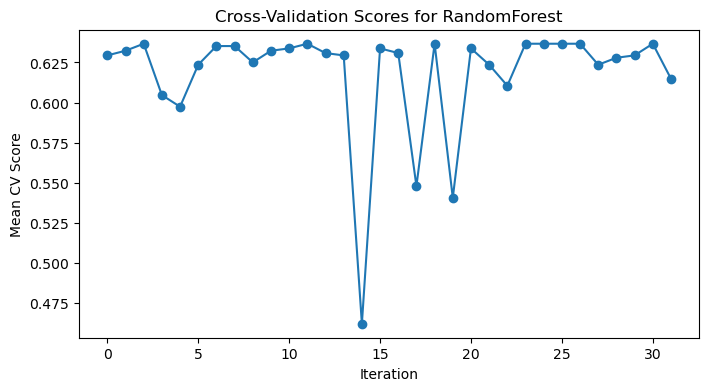

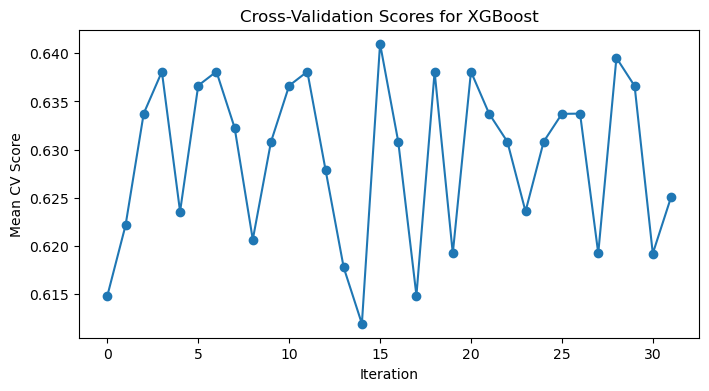

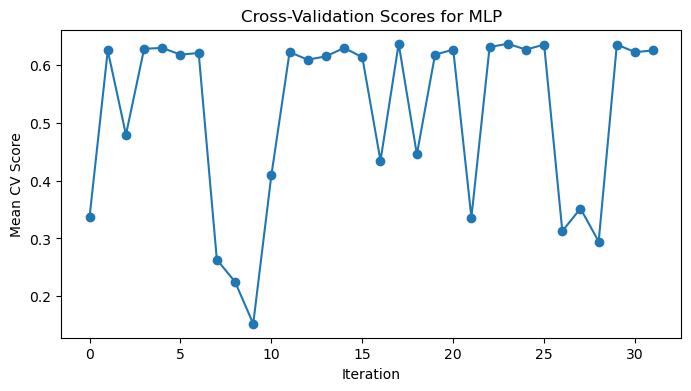

In [ ]:
import matplotlib.pyplot as plt

def plot_cv_scores(search, model_name):
    scores = search.cv_results_["mean_test_score"]
    plt.figure(figsize=(8,4))
    plt.plot(scores, marker='o')
    plt.title(f"Cross-Validation Scores for {model_name}")
    plt.xlabel("Iteration")
    plt.ylabel("Mean CV Score")
    plt.show()

# Example usage:
plot_cv_scores(rf_bayes, "RandomForest")
plot_cv_scores(xgb_bayes, "XGBoost")
plot_cv_scores(mlp_bayes, "MLP")